# Notebook 6: Probability Distributions

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What is a Probability Distribution?

A probability distribution tells us **all possible values of a random variable and how likely each value is**.

- **Discrete distributions** (countable values): Bernoulli, Binomial, Poisson. They use a PMF (Probability Mass Function).
- **Continuous distributions** (any value in a range): Uniform, Normal, Exponential. They use a PDF (Probability Density Function), and probability is the **area under the curve**.

**Analogy:** A distribution is like a menu with probabilities. Each possible outcome is a dish, and the probability tells us how often it gets ordered.

**Why it matters in AI/ML:** Choosing the right distribution to model data (clicks, counts, waiting times, errors) decides the right model, loss function and statistical test.

**Topics covered:** Bernoulli, Binomial, Poisson, Uniform, Normal, Exponential.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

## 1. Bernoulli Distribution

**Definition:** A Bernoulli distribution models **one trial with only two outcomes**: success (1) with probability p, or failure (0) with probability 1 - p.

**Formula:**

$$P(X = x) = p^x (1 - p)^{1 - x}, \quad x \in \{0, 1\}$$

$$Mean = p \qquad Variance = p(1 - p)$$

**Where it is used:** Any yes/no event: click or no click, pass or fail, fraud or not fraud.

**Real-world Example:** A user sees an ad. The probability that they click is p = 0.3. So P(click) = 0.3 and P(no click) = 0.7.

**Numerical Example:** For p = 0.3, Mean = 0.3 and Variance = 0.3 × 0.7 = **0.21**.

**AI/ML Example:** **Binary classification** (spam / not spam). Logistic Regression models the target as Bernoulli with probability p, and **Binary Cross-Entropy loss** comes from the Bernoulli likelihood.

P(X=1): 0.3
P(X=0): 0.7000000000000002
Mean  : 0.3 | Variance: 0.21
Simulated click rate: 0.2887


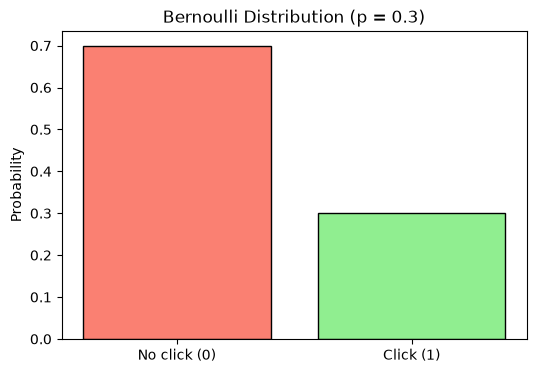

In [2]:
p = 0.3
bern = stats.bernoulli(p)

print("P(X=1):", bern.pmf(1))
print("P(X=0):", bern.pmf(0))
print("Mean  :", bern.mean(), "| Variance:", round(bern.var(), 2))

# Simulation: 10000 users seeing the ad
samples = bern.rvs(size=10000)
print("Simulated click rate:", samples.mean())

plt.figure(figsize=(6, 4))
plt.bar([0, 1], [bern.pmf(0), bern.pmf(1)], color=["salmon", "lightgreen"], edgecolor="black")
plt.xticks([0, 1], ["No click (0)", "Click (1)"])
plt.title("Bernoulli Distribution (p = 0.3)")
plt.ylabel("Probability")
plt.show()

**Explanation:** We create a Bernoulli distribution with p = 0.3, read the probabilities of 0 and 1, then simulate 10,000 users. The bar chart shows the two possible outcomes.

**Interpretation:** There are only two bars, and they add up to 1. The simulated click rate is close to 0.3. A Bernoulli trial is the **building block** for the Binomial distribution.

## 2. Binomial Distribution

**Definition:** A Binomial distribution counts the **number of successes in n independent Bernoulli trials**, each with the same success probability p.

**Formula:**

$$P(X = k) = \binom{n}{k} p^k (1 - p)^{n - k}$$

$$Mean = np \qquad Variance = np(1 - p)$$

**Conditions:** fixed number of trials n, only two outcomes per trial, independent trials, constant p.

**Where it is used:** Counting successes out of a fixed number of attempts: defective items in a batch, conversions out of visitors, correct predictions out of test samples.

**Real-world Example:** Tossing a fair coin 10 times. What is the probability of exactly 6 heads?

**Numerical Example:** n = 10, p = 0.5, k = 6
P(X = 6) = C(10, 6) × 0.5^6 × 0.5^4 = 210 × (1/1024) = **0.2051**
Mean = 10 × 0.5 = **5** heads.

**AI/ML Example:** The number of correct predictions of a classifier on n test samples is Binomial(n, accuracy). This is used to build **confidence intervals for accuracy** and in **A/B testing** (conversions out of visitors).

P(exactly 6 heads): 0.2051
P(at most 3 heads): 0.1719
P(at least 8 heads): 0.0547
Mean: 5.0 | Variance: 2.5
Simulated P(6 heads): 0.2064


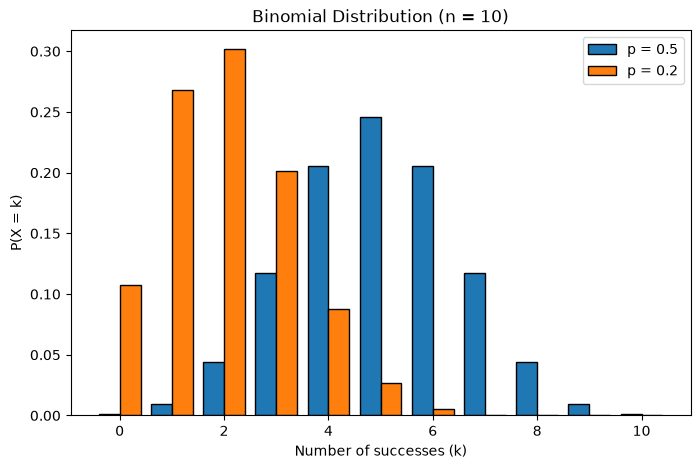

In [3]:
n, p = 10, 0.5

print("P(exactly 6 heads):", round(stats.binom.pmf(6, n, p), 4))
print("P(at most 3 heads):", round(stats.binom.cdf(3, n, p), 4))
print("P(at least 8 heads):", round(1 - stats.binom.cdf(7, n, p), 4))
print("Mean:", stats.binom.mean(n, p), "| Variance:", stats.binom.var(n, p))

# Simulation
sim = np.random.binomial(n, p, size=100000)
print("Simulated P(6 heads):", round(np.mean(sim == 6), 4))

# Visualization: different p values
k = np.arange(0, n + 1)
plt.figure(figsize=(8, 5))
plt.bar(k - 0.2, stats.binom.pmf(k, n, 0.5), width=0.4, label="p = 0.5", edgecolor="black")
plt.bar(k + 0.2, stats.binom.pmf(k, n, 0.2), width=0.4, label="p = 0.2", edgecolor="black")
plt.title("Binomial Distribution (n = 10)")
plt.xlabel("Number of successes (k)")
plt.ylabel("P(X = k)")
plt.legend()
plt.show()

**Explanation:** `stats.binom.pmf(k, n, p)` gives the probability of exactly k successes. `cdf` gives the probability of k or fewer. We confirm the result by simulating 100,000 experiments and compare two values of p in one chart.

**Interpretation:** For p = 0.5 the chart is symmetric and centered at 5. For p = 0.2 it shifts to the left (centered at 2) and becomes skewed. The probability of exactly 6 heads is about 0.205. Notice that even the most likely outcome has a probability of only about 25%.

## 3. Poisson Distribution

**Definition:** A Poisson distribution counts the **number of events that happen in a fixed interval of time or space**, when events occur independently at a constant average rate λ (lambda).

**Formula:**

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

$$Mean = \lambda \qquad Variance = \lambda$$

(In a Poisson distribution, the mean and the variance are equal.)

**Where it is used:** Counting rare or random events per interval: calls per hour, customers per minute, accidents per day, server errors per hour.

**Real-world Example:** A help desk receives on average 4 calls per hour. What is the probability of exactly 2 calls in the next hour?

**Numerical Example:** λ = 4, k = 2
P(X = 2) = (4² × e^-4) / 2! = (16 × 0.0183) / 2 = **0.1465**

**AI/ML Example:** **Poisson Regression** predicts count data (number of orders, number of clicks). It is also used in word-count models for text, and for modeling the number of requests to a server in capacity planning.

P(exactly 2 calls) : 0.1465
P(0 calls)         : 0.0183
P(8 or more calls) : 0.0511
Mean: 4.0 | Variance: 4.0
Simulated mean: 4.005 | Simulated variance: 4.003


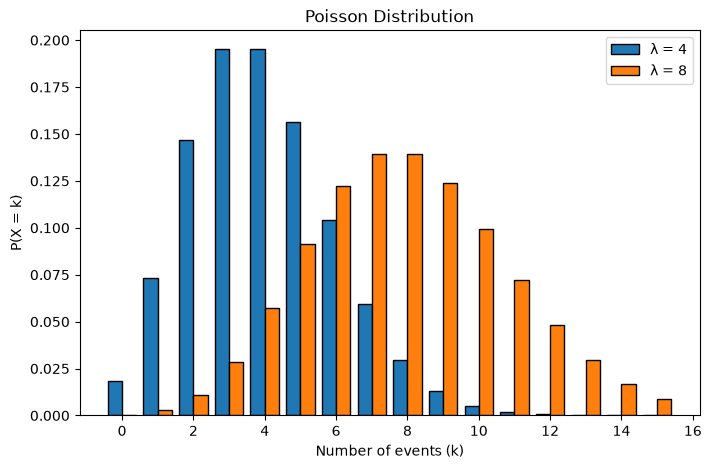

In [4]:
lam = 4

print("P(exactly 2 calls) :", round(stats.poisson.pmf(2, lam), 4))
print("P(0 calls)         :", round(stats.poisson.pmf(0, lam), 4))
print("P(8 or more calls) :", round(1 - stats.poisson.cdf(7, lam), 4))
print("Mean:", stats.poisson.mean(lam), "| Variance:", stats.poisson.var(lam))

# Simulation
sim = np.random.poisson(lam, size=100000)
print("Simulated mean:", round(sim.mean(), 3), "| Simulated variance:", round(sim.var(), 3))

# Visualization
k = np.arange(0, 16)
plt.figure(figsize=(8, 5))
plt.bar(k - 0.2, stats.poisson.pmf(k, 4), width=0.4, label="λ = 4", edgecolor="black")
plt.bar(k + 0.2, stats.poisson.pmf(k, 8), width=0.4, label="λ = 8", edgecolor="black")
plt.title("Poisson Distribution")
plt.xlabel("Number of events (k)")
plt.ylabel("P(X = k)")
plt.legend()
plt.show()

**Explanation:** `stats.poisson.pmf(k, λ)` gives the probability of exactly k events. We also simulate 100,000 hours and compare the mean and variance, and plot two different rates.

**Interpretation:** The probability of exactly 2 calls is about 14.65%. The simulated mean and variance are both close to 4, which confirms that **mean = variance** for Poisson. A larger λ shifts the distribution to the right and makes it wider and more bell-shaped.

## 4. Uniform Distribution

**Definition:** In a uniform distribution, **every value between a and b is equally likely**. The density is a flat line.

**Formula:**

$$f(x) = \frac{1}{b - a}, \quad a \le x \le b$$

$$P(c \le X \le d) = \frac{d - c}{b - a}$$

$$Mean = \frac{a + b}{2} \qquad Variance = \frac{(b - a)^2}{12}$$

**Where it is used:** Random number generation, random sampling, situations where we have no reason to prefer any value.

**Real-world Example:** A bus comes every 20 minutes and you arrive at a random time. Your waiting time is uniform between 0 and 20 minutes.

**Numerical Example:** a = 0, b = 20
P(wait between 5 and 10 min) = (10 - 5) / 20 = **0.25**
Mean = **10 min**, Variance = 400 / 12 = **33.33**

**AI/ML Example:** Random weight initialization (Xavier / Glorot uniform), random train-test splits, and **random search** for hyperparameters all draw from uniform distributions.

P(5 <= wait <= 10): 0.25
Mean: 10.0 | Variance: 33.33
Simulated P(5 <= wait <= 10): 0.2527


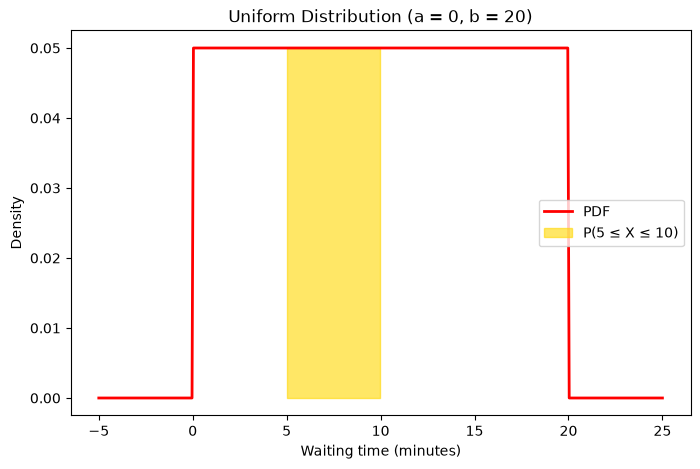

In [5]:
a, b = 0, 20
unif = stats.uniform(loc=a, scale=b - a)   # scipy uses loc = a, scale = b - a

print("P(5 <= wait <= 10):", round(unif.cdf(10) - unif.cdf(5), 4))
print("Mean:", unif.mean(), "| Variance:", round(unif.var(), 2))

sim = unif.rvs(size=100000)
print("Simulated P(5 <= wait <= 10):", round(np.mean((sim >= 5) & (sim <= 10)), 4))

x = np.linspace(-5, 25, 400)
plt.figure(figsize=(8, 5))
plt.plot(x, unif.pdf(x), "r-", linewidth=2, label="PDF")
plt.fill_between(x, unif.pdf(x), where=(x >= 5) & (x <= 10), color="gold", alpha=0.6, label="P(5 ≤ X ≤ 10)")
plt.title("Uniform Distribution (a = 0, b = 20)")
plt.xlabel("Waiting time (minutes)")
plt.ylabel("Density")
plt.legend()
plt.show()

**Explanation:** In SciPy, a uniform distribution on [a, b] is created with `loc = a` and `scale = b - a`. The probability between 5 and 10 is the difference of two CDF values, and it is the shaded area under the flat line.

**Interpretation:** The area is 5 × (1/20) = 0.25, which matches both the formula and the simulation. For continuous distributions, **probability = area under the curve**, and the probability of any single exact value is 0.

## 5. Normal Distribution

**Definition:** The normal (Gaussian) distribution is a symmetric bell-shaped continuous distribution, completely defined by its mean μ and standard deviation σ.

**Formula:**

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

$$Z = \frac{x - \mu}{\sigma}$$

**Where it is used:** Natural measurements (height, weight, marks), measurement errors, and sums or averages of many random effects (Central Limit Theorem).

**Real-world Example:** Exam marks with μ = 70 and σ = 10. What is the probability that a student scores above 85?

**Numerical Example:**
Z = (85 - 70) / 10 = 1.5
P(X > 85) = 1 - P(Z < 1.5) = 1 - 0.9332 = **0.0668** (about 6.7%)
P(60 < X < 80) is within 1σ, so about **0.6827**.

**AI/ML Example:** Linear Regression assumes normally distributed errors. Neural network weights are initialized from a normal distribution. **Gaussian Naive Bayes**, **Gaussian Mixture Models** and the latent space of **VAEs** are all built on the normal distribution.

P(X > 85)      : 0.0668
P(60 < X < 80) : 0.6827
Marks below which 90% of students fall: 82.82
Simulated P(X > 85): 0.0674


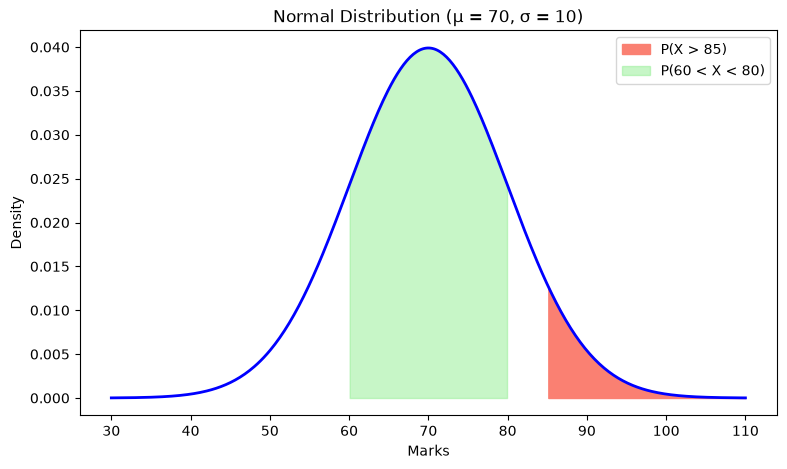

In [6]:
mu, sigma = 70, 10
norm = stats.norm(mu, sigma)

print("P(X > 85)      :", round(1 - norm.cdf(85), 4))
print("P(60 < X < 80) :", round(norm.cdf(80) - norm.cdf(60), 4))
print("Marks below which 90% of students fall:", round(norm.ppf(0.90), 2))

sim = norm.rvs(size=100000)
print("Simulated P(X > 85):", round(np.mean(sim > 85), 4))

x = np.linspace(30, 110, 400)
plt.figure(figsize=(9, 5))
plt.plot(x, norm.pdf(x), "b-", linewidth=2)
plt.fill_between(x, norm.pdf(x), where=(x >= 85), color="salmon", label="P(X > 85)")
plt.fill_between(x, norm.pdf(x), where=(x >= 60) & (x <= 80), color="lightgreen", alpha=0.5, label="P(60 < X < 80)")
plt.title("Normal Distribution (μ = 70, σ = 10)")
plt.xlabel("Marks")
plt.ylabel("Density")
plt.legend()
plt.show()

**Explanation:** `norm.cdf(x)` gives P(X ≤ x), so P(X > 85) is `1 - cdf`. `norm.ppf(0.90)` is the inverse, which gives the value below which 90% of data falls. The shaded areas show the probabilities.

**Interpretation:** About 6.7% of students score above 85, and about 68% score between 60 and 80. The top 10% of students score above about 82.8. The bell curve is the same shape for any μ and σ, only shifted and stretched.

## 6. Exponential Distribution

**Definition:** The exponential distribution models the **waiting time until the next event** in a process where events happen independently at a constant average rate λ.

**Formula:**

$$f(x) = \lambda e^{-\lambda x}, \quad x \ge 0$$

$$P(X \le x) = 1 - e^{-\lambda x}$$

$$Mean = \frac{1}{\lambda} \qquad Variance = \frac{1}{\lambda^2}$$

**Key property:** It is **memoryless**. If you have already waited 10 minutes, the remaining waiting time has the same distribution as when you started.

**Relation with Poisson:** If the number of events per hour is Poisson(λ), the time **between** events is Exponential(λ).

**Where it is used:** Time between customer arrivals, time until a machine fails, time between server requests.

**Real-world Example:** Calls arrive at a rate λ = 4 per hour. What is the probability that the next call comes within 10 minutes (1/6 hour)?

**Numerical Example:**
P(X ≤ 1/6) = 1 - e^(-4 × 1/6) = 1 - e^(-0.667) = 1 - 0.5134 = **0.4866**
Mean waiting time = 1/4 hour = **15 minutes**.

**AI/ML Example:** **Survival analysis** (time until customer churn or machine failure), modeling time between events in queueing systems, and the exponential decay used in learning-rate schedules and moving averages.

P(wait <= 10 min): 0.4866
P(wait > 30 min) : 0.1353
Mean wait (minutes): 15.0
Simulated P(wait <= 10 min): 0.4848

P(X > 0.5): 0.1356
P(X > 1.0 | X > 0.5): 0.1416


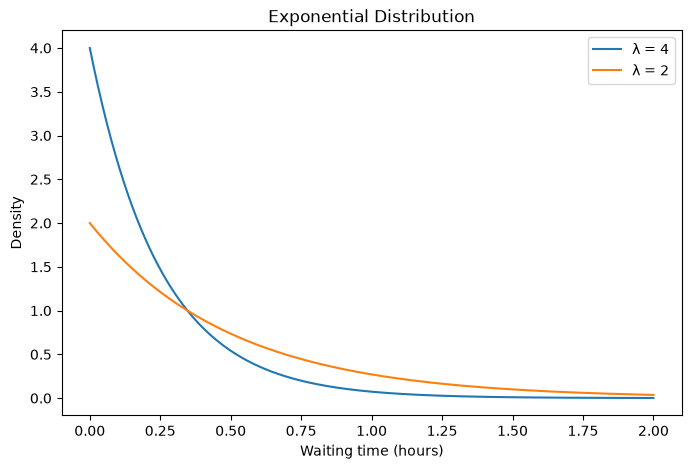

In [7]:
lam = 4                      # events per hour
expo = stats.expon(scale=1 / lam)   # scipy uses scale = 1/λ

print("P(wait <= 10 min):", round(expo.cdf(1 / 6), 4))
print("P(wait > 30 min) :", round(1 - expo.cdf(0.5), 4))
print("Mean wait (minutes):", expo.mean() * 60)

sim = expo.rvs(size=100000)
print("Simulated P(wait <= 10 min):", round(np.mean(sim <= 1 / 6), 4))

# Memoryless check: P(X > 1.0 | X > 0.5) should equal P(X > 0.5)
p_after_wait = np.mean(sim[sim > 0.5] > 1.0)
print("\nP(X > 0.5):", round(np.mean(sim > 0.5), 4))
print("P(X > 1.0 | X > 0.5):", round(p_after_wait, 4))

x = np.linspace(0, 2, 400)
plt.figure(figsize=(8, 5))
plt.plot(x, stats.expon(scale=1 / 4).pdf(x), label="λ = 4")
plt.plot(x, stats.expon(scale=1 / 2).pdf(x), label="λ = 2")
plt.title("Exponential Distribution")
plt.xlabel("Waiting time (hours)")
plt.ylabel("Density")
plt.legend()
plt.show()

**Explanation:** SciPy uses `scale = 1/λ` for the exponential distribution. We calculate probabilities with `cdf`, simulate waiting times, and test the memoryless property.

**Interpretation:** There is a 48.7% chance the next call arrives within 10 minutes, and the mean wait is 15 minutes. The curve starts high and decays: short waits are the most likely. The two conditional probabilities are almost equal, which confirms the **memoryless** property. A higher λ (more frequent events) gives a steeper curve with shorter waits.

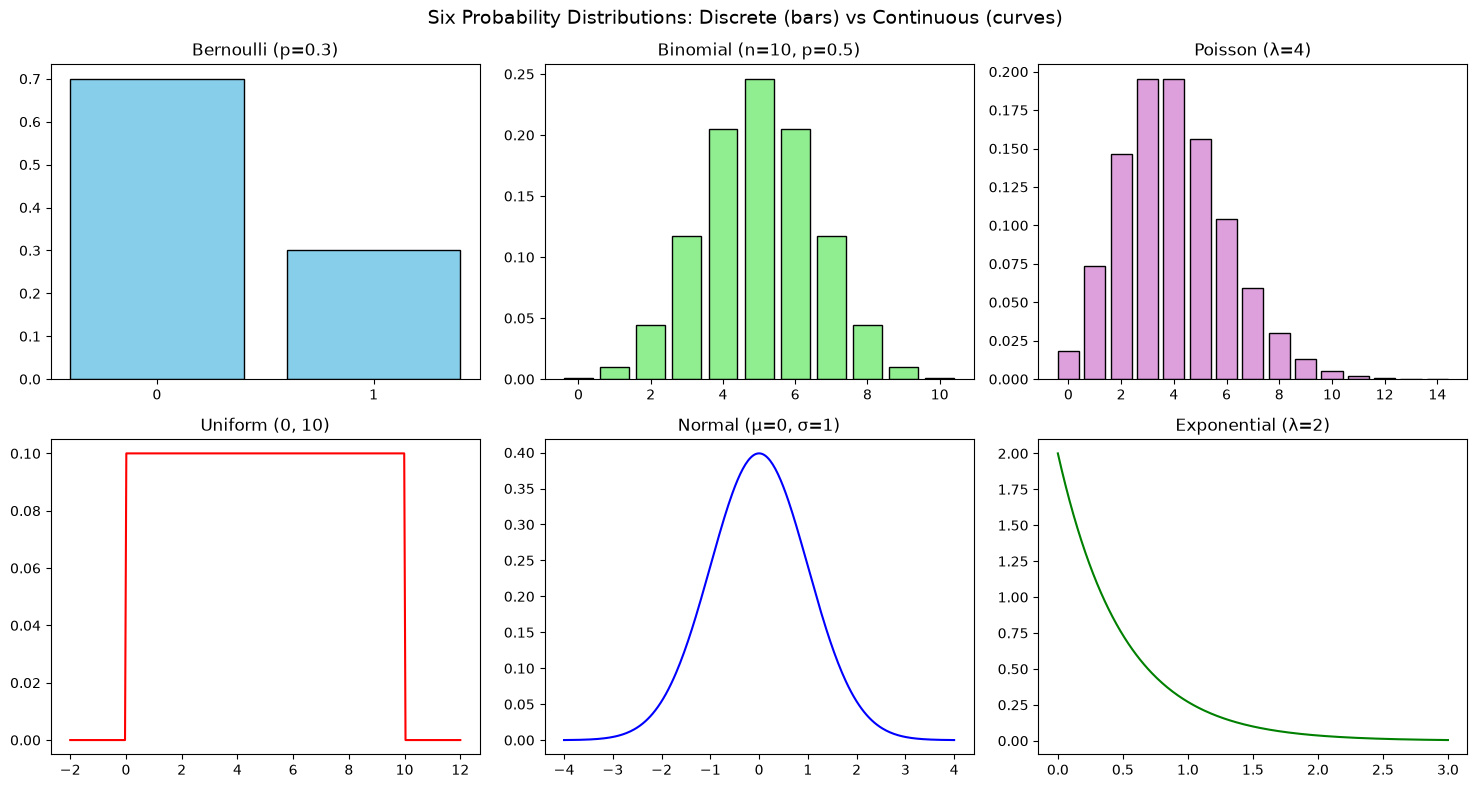

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Bernoulli
axes[0, 0].bar([0, 1], stats.bernoulli(0.3).pmf([0, 1]), color="skyblue", edgecolor="black")
axes[0, 0].set_title("Bernoulli (p=0.3)")
axes[0, 0].set_xticks([0, 1])

# Binomial
k = np.arange(0, 11)
axes[0, 1].bar(k, stats.binom.pmf(k, 10, 0.5), color="lightgreen", edgecolor="black")
axes[0, 1].set_title("Binomial (n=10, p=0.5)")

# Poisson
k = np.arange(0, 15)
axes[0, 2].bar(k, stats.poisson.pmf(k, 4), color="plum", edgecolor="black")
axes[0, 2].set_title("Poisson (λ=4)")

# Uniform
x = np.linspace(-2, 12, 300)
axes[1, 0].plot(x, stats.uniform(0, 10).pdf(x), "r-")
axes[1, 0].set_title("Uniform (0, 10)")

# Normal
x = np.linspace(-4, 4, 300)
axes[1, 1].plot(x, stats.norm.pdf(x), "b-")
axes[1, 1].set_title("Normal (μ=0, σ=1)")

# Exponential
x = np.linspace(0, 3, 300)
axes[1, 2].plot(x, stats.expon(scale=1 / 2).pdf(x), "g-")
axes[1, 2].set_title("Exponential (λ=2)")

plt.suptitle("Six Probability Distributions: Discrete (bars) vs Continuous (curves)", fontsize=14)
plt.tight_layout()
plt.show()

**Explanation:** One figure shows all six distributions. Discrete distributions are drawn as **bars** (separate values), and continuous distributions as **smooth curves**.

**Interpretation:** Bernoulli, Binomial and Poisson are discrete. Uniform, Normal and Exponential are continuous. Binomial with large n starts to look like a bell curve, and Poisson with large λ does too, both approach the normal distribution.

## Summary: Which Distribution to Use?

| Distribution | Type | Models | Parameters | Mean | Variance |
|---|---|---|---|---|---|
| Bernoulli | Discrete | One yes/no trial | p | p | p(1-p) |
| Binomial | Discrete | Number of successes in n trials | n, p | np | np(1-p) |
| Poisson | Discrete | Number of events in an interval | λ | λ | λ |
| Uniform | Continuous | All values equally likely | a, b | (a+b)/2 | (b-a)²/12 |
| Normal | Continuous | Bell-shaped natural data | μ, σ | μ | σ² |
| Exponential | Continuous | Waiting time until next event | λ | 1/λ | 1/λ² |

**Quick decision guide:**
- One yes/no outcome → **Bernoulli**
- Count of successes out of a fixed n → **Binomial**
- Count of events per time/space interval → **Poisson**
- Time between events → **Exponential**
- Everything equally likely in a range → **Uniform**
- Symmetric bell-shaped measurement → **Normal**

## Advantages
- Gives a mathematical model of how data behaves, so we can calculate probabilities
- Helps choose the right ML model and loss function (Bernoulli → Logistic Regression, Poisson → count regression)
- Allows simulation and prediction of real-world processes
- Many statistical tests are built on these distributions

## Limitations
- Real data rarely follows a distribution perfectly
- Each distribution has assumptions (independence, constant rate, constant p) that may not hold
- Poisson fails when variance is much larger than the mean (overdispersion)
- Wrong distribution choice leads to wrong probabilities and wrong conclusions